In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv('Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


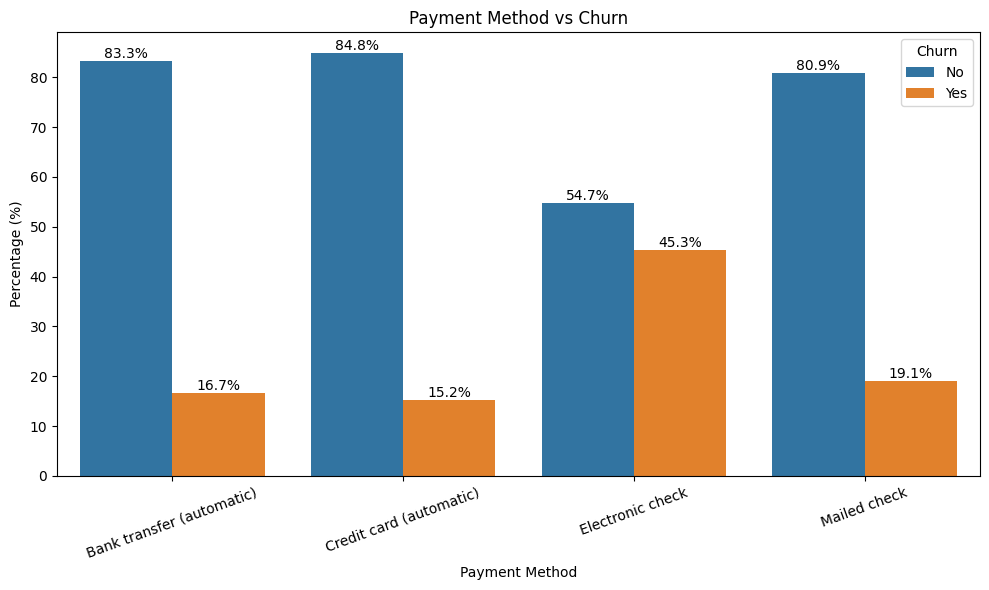

In [9]:
Payment_Churn = (
    df.groupby('PaymentMethod')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('percentage')
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=Payment_Churn,
    x='PaymentMethod',
    y='percentage',
    hue='Churn'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Payment Method vs Churn')
plt.xlabel('Payment Method')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=20)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

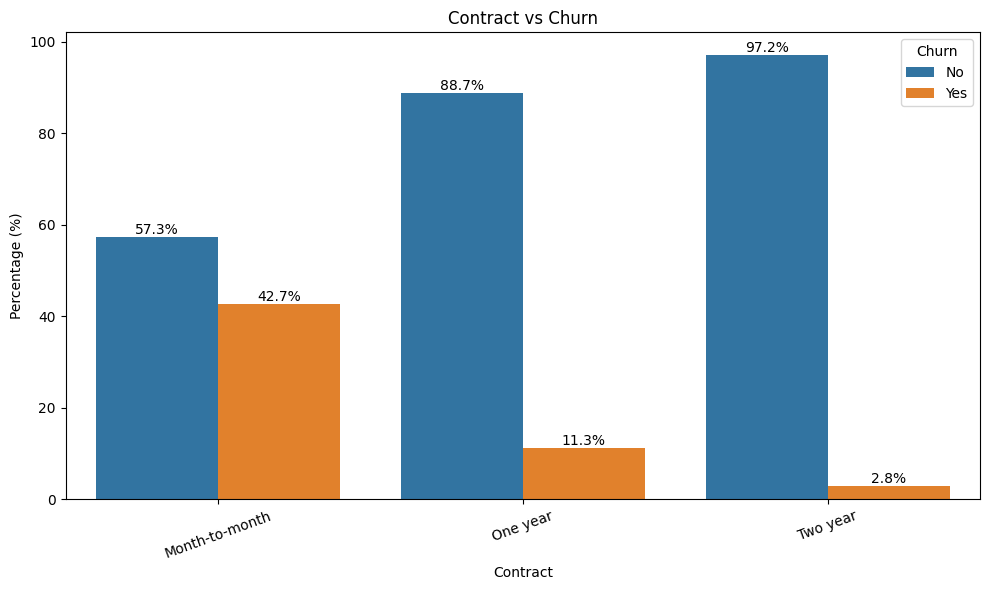

In [10]:
Contract_Churn=(
    df.groupby('Contract')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('percentage')
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=Contract_Churn,
    x='Contract',
    y='percentage',
    hue='Churn'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Contract vs Churn')
plt.xlabel('Contract')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=20)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

### 💡 Insight 1: Contract Type and Payment Method Influence Customer Churn

**Observation:**

Customers with **Month-to-Month contracts** experienced the highest churn rate (**42.7%**), whereas customers with **One-Year (11.3%)** and **Two-Year (2.8%)** contracts were significantly less likely to churn. Additionally, customers using **Electronic Check** as their payment method recorded the highest churn rate (**45.3%**) compared to all other payment methods.

**Business Insight:**

The high churn among Electronic Check users is likely associated with the flexibility of **Month-to-Month contracts**, which allow customers to switch providers without long-term commitments. In contrast, customers enrolled in longer-term contracts are more likely to remain with the company, resulting in substantially lower churn rates.

**Recommendation:**

Encourage customers to transition from **Month-to-Month** to **One-Year** or **Two-Year** contracts through loyalty rewards, discounts, or bundled service plans. Additionally, promote **automatic payment methods** such as Credit Card or Bank Transfer by offering incentives, as these customers exhibit considerably lower churn rates.

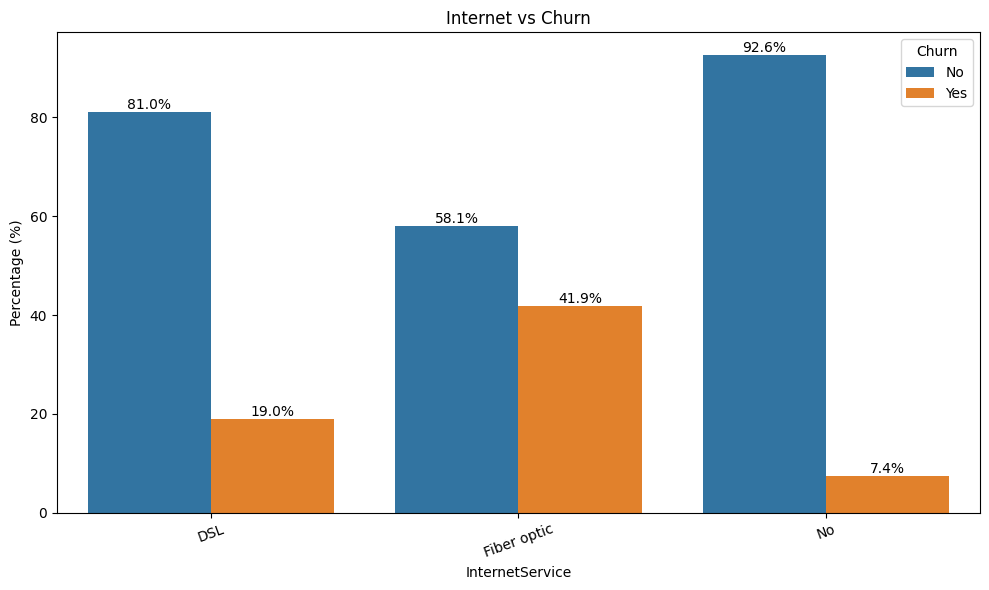

In [13]:
Internet_Churn=(
    df.groupby('InternetService')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('percentage')
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=Internet_Churn,
    x='InternetService',
    y='percentage',
    hue='Churn'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Internet vs Churn')
plt.xlabel('InternetService')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=20)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

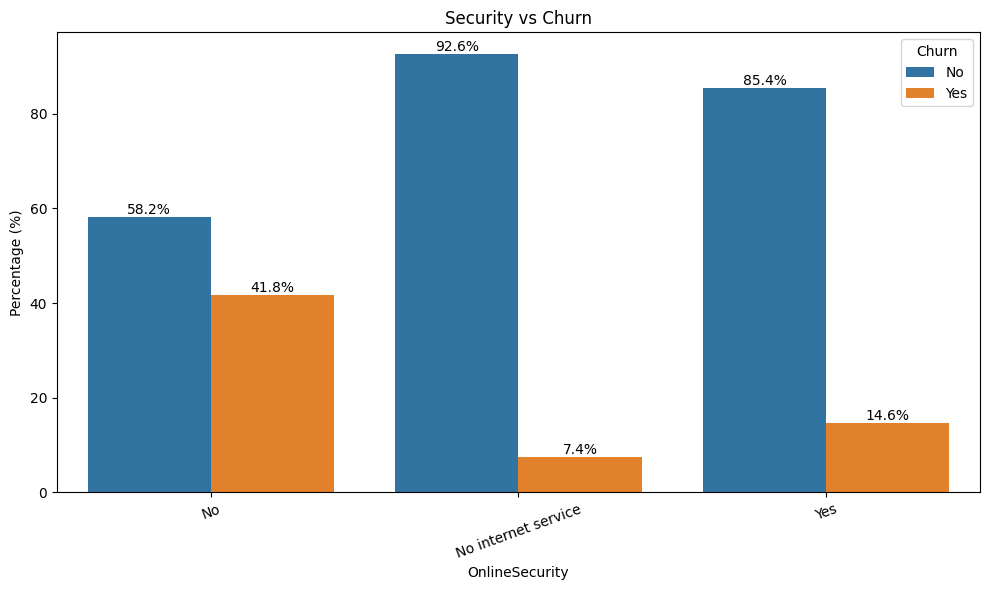

In [16]:
Security_Churn=(
    df.groupby('OnlineSecurity')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('percentage')
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=Security_Churn,
    x='OnlineSecurity',
    y='percentage',
    hue='Churn'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Security vs Churn')
plt.xlabel('OnlineSecurity')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=20)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

### 💡 Insight 2: Internet Service and Online Security Significantly Influence Customer Churn

**Observation:**

Customers using **Fiber Optic** internet service experienced the highest churn rate (**41.9%**), compared to customers using **DSL (19.0%)** or those without an internet service (**7.4%)**. Furthermore, customers **without Online Security** recorded a significantly higher churn rate (**41.8%**) than customers who subscribed to the Online Security service (**14.6%**).

**Business Insight:**

The high churn observed among Fiber Optic customers is likely associated with the absence of **Online Security** services. Customers who do not subscribe to Online Security may perceive lower value from their internet plans or have greater concerns regarding online safety, making them more likely to switch to competing providers. In contrast, customers who use Online Security demonstrate much higher retention, indicating that value-added services improve customer loyalty.

**Recommendation:**

Increase the adoption of **Online Security** by bundling it with Fiber Optic internet plans, offering promotional pricing, or providing free trial periods. Enhancing the value of Fiber Optic packages through security services may improve customer satisfaction and help reduce churn.

In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


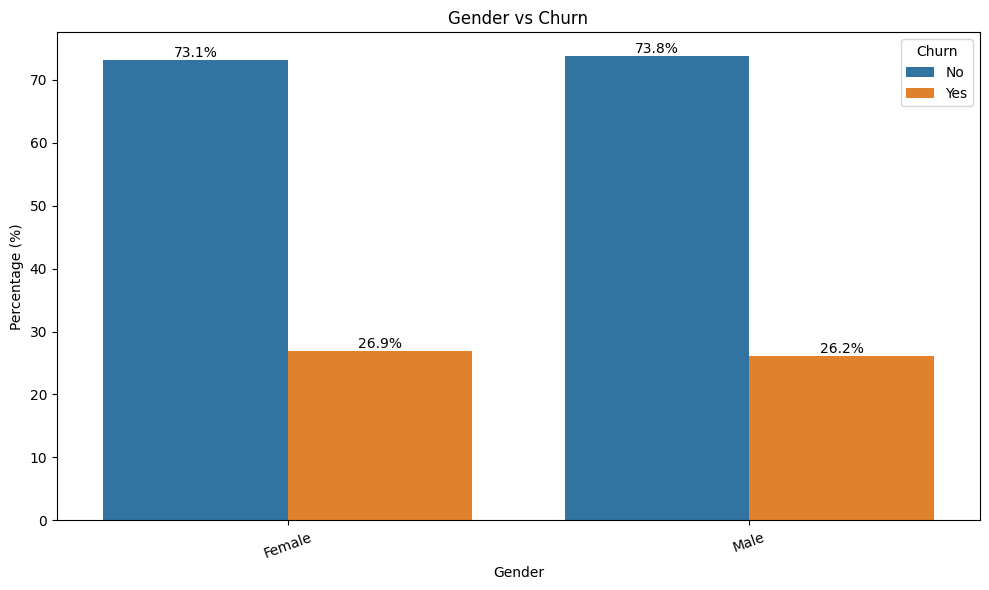

In [18]:
Gender_Churn=(
    df.groupby('gender')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('percentage')
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=Gender_Churn,
    x='gender',
    y='percentage',
    hue='Churn'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Gender vs Churn')
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=20)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

### 💡 Insight 4: Gender Has Minimal Influence on Customer Churn

**Observation:**

The churn rates for **Female (26.9%)** and **Male (26.2%)** customers are nearly identical, with a difference of less than **1 percentage point**.

**Business Insight:**

The analysis indicates that **gender is not significantly associated with customer churn**. Customers of both genders exhibit similar retention behavior, suggesting that demographic characteristics such as gender have little influence on a customer's decision to leave the telecom service. Instead, service-related factors such as **contract type, internet service, online security, and tenure** are likely to play a much more important role in customer retention.

**Recommendation:**

Customer retention strategies should focus on **service quality, contract plans, pricing, and value-added features** rather than designing gender-specific marketing or retention campaigns. Prioritizing improvements in customer experience is likely to have a greater impact on reducing churn.

In [21]:
df['Tenure Group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,36,48,60,72],
    labels=[
        '0-12',
        '13-24',
        '25-36',
        '37-48',
        '49-60',
        '61-72'
    ]
)

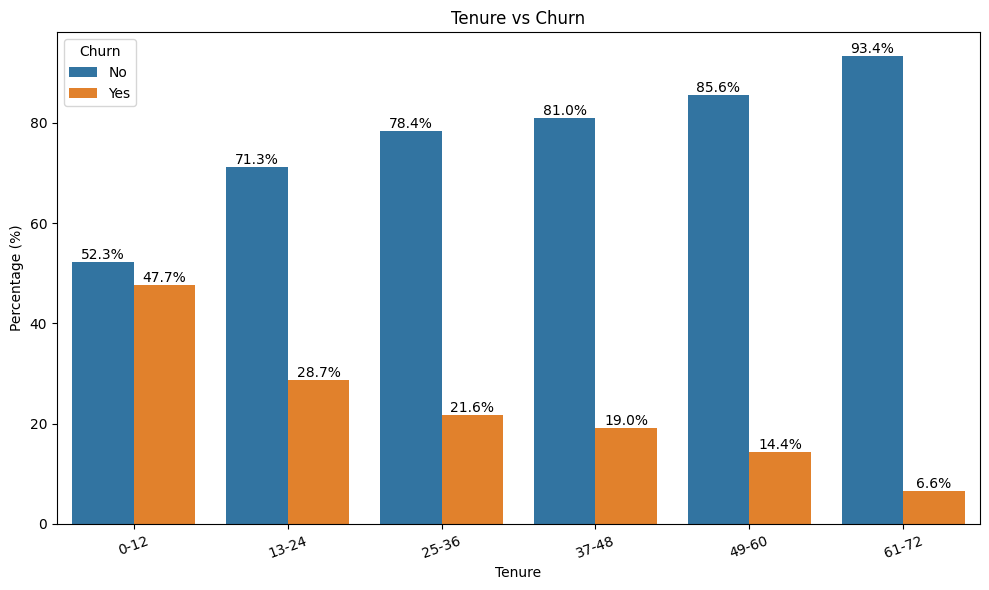

In [27]:
Tenure_Churn=(
    df.groupby('Tenure Group')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('percentage')
      .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=Tenure_Churn,
    x='Tenure Group',
    y='percentage',
    hue='Churn'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Tenure vs Churn')
plt.xlabel('Tenure')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=20)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

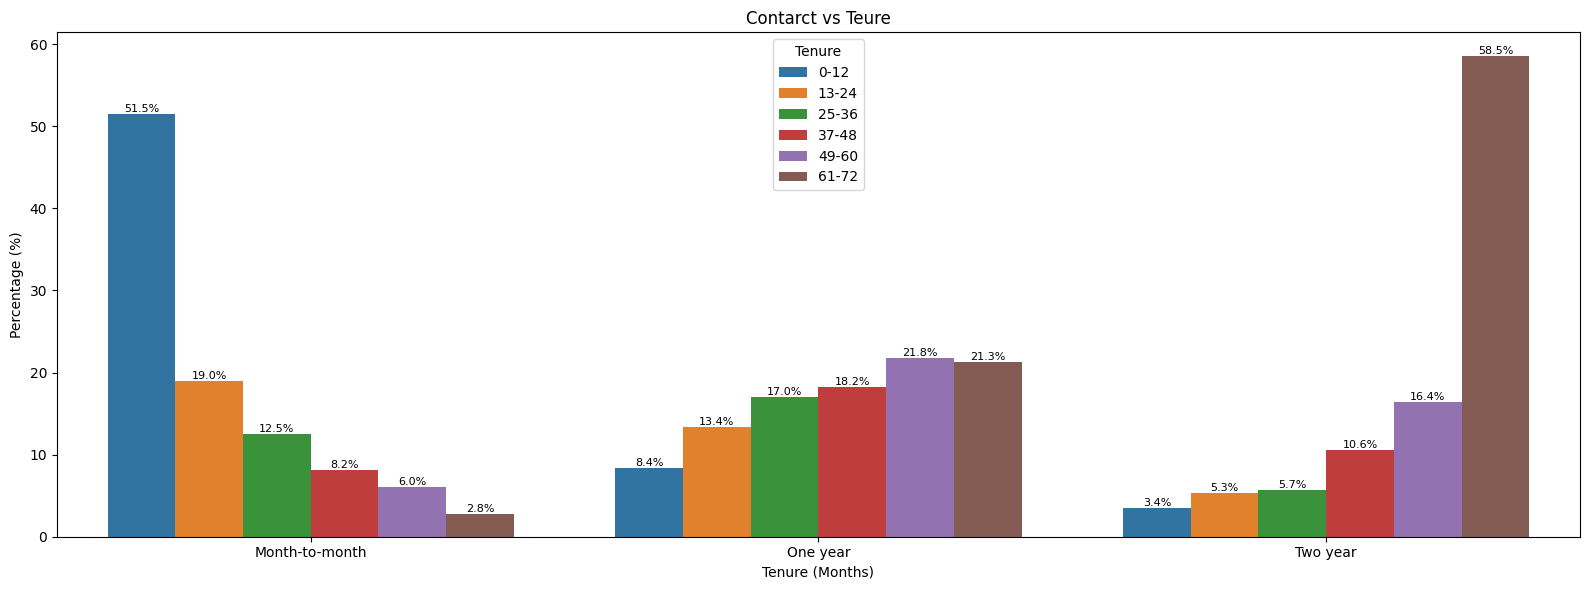

In [31]:
Tenure_Churn = (
    df.groupby('Contract')['Tenure Group']
      .value_counts(normalize=True)
      .mul(100)
      .rename('percentage')
      .reset_index()
)

plt.figure(figsize=(16,6))

ax = sns.barplot(
    data=Tenure_Churn,
    x='Contract',
    y='percentage',
    hue='Tenure Group'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.title('Contarct vs Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Percentage (%)')
plt.legend(title='Tenure')
plt.tight_layout()
plt.show()

### 💡 Insight 3: Customer Tenure and Contract Duration Strongly Influence Churn

**Observation:**

Customers in the **0–12 month** tenure group experienced the highest churn rate (**47.7%**), while churn steadily decreased as customer tenure increased, reaching only **6.6%** among customers who had remained with the company for **61–72 months**.

**Business Insight:**

The supporting analysis reveals that **Month-to-Month contracts are predominantly held by newer customers**, with over **51%** of these customers belonging to the **0–12 month** tenure group. In contrast, **58.5%** of customers with **Two-Year contracts** have remained with the company for **61–72 months**, demonstrating significantly stronger customer loyalty. This suggests that longer contract commitments encourage customer retention and reduce the likelihood of churn.

**Recommendation:**

Strengthen customer retention during the **first year** by improving onboarding, offering personalized engagement, and providing incentives to upgrade from **Month-to-Month** to **One-Year** or **Two-Year** contracts. Encouraging long-term contracts can significantly improve customer retention and reduce churn.

In [32]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   object  
 4   Dependents        7043 non-null   object  
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   object  
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

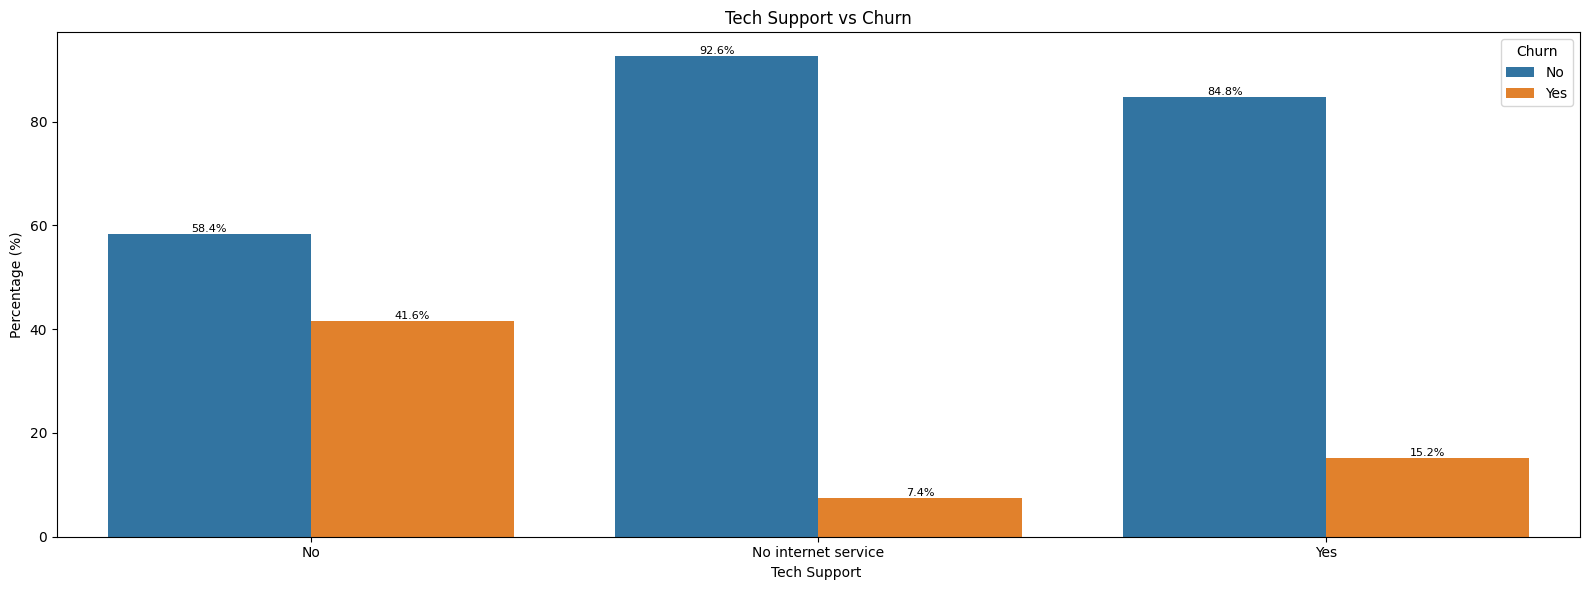

In [39]:
Tech_Churn = (
    df.groupby('TechSupport')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('percentage')
      .reset_index()
)

plt.figure(figsize=(16,6))

ax = sns.barplot(
    data=Tech_Churn,
    x='TechSupport',
    y='percentage',
    hue='Churn'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.title('Tech Support vs Churn')
plt.xlabel('Tech Support ')
plt.ylabel('Percentage (%)')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

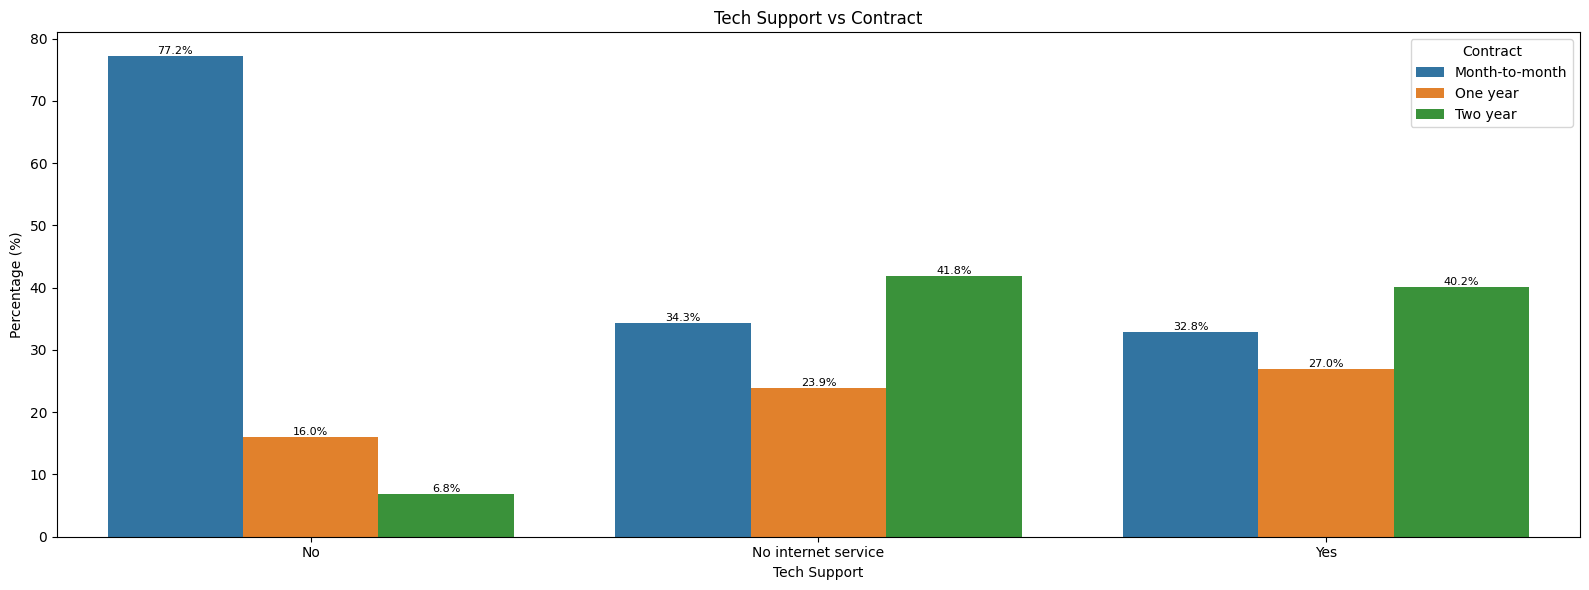

In [38]:
Tech_Contract_Churn = (
    df.groupby('TechSupport')['Contract']
      .value_counts(normalize=True)
      .mul(100)
      .rename('percentage')
      .reset_index()
)

plt.figure(figsize=(16,6))

ax = sns.barplot(
    data=Tech_Contract_Churn,
    x='TechSupport',
    y='percentage',
    hue='Contract'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.title('Tech Support vs Contract')
plt.xlabel('Tech Support')
plt.ylabel('Percentage (%)')
plt.legend(title='Contract')
plt.tight_layout()
plt.show()

### 💡 Insight 5: Lack of Technical Support Is Associated with Higher Customer Churn

**Observation:**

Customers **without Tech Support** experienced a significantly higher churn rate (**41.6%**) compared to customers who subscribed to **Tech Support (15.2%)**. Customers without an internet service recorded the lowest churn rate (**7.4%**), as technical support is generally not required for these customers.

**Business Insight:**

The supporting analysis shows that **77.2%** of customers without Tech Support are enrolled in **Month-to-Month contracts**, while only **6.8%** have **Two-Year contracts**. In contrast, customers with Tech Support are more likely to have long-term contracts, with **40.2%** subscribed to **Two-Year plans**. This suggests that the absence of technical support, combined with flexible contract plans, is associated with higher customer churn.

**Recommendation:**

Encourage customers to subscribe to **Tech Support** through bundled service packages or promotional offers. Additionally, motivate Month-to-Month customers to transition to longer-term contracts, as combining value-added support services with long-term commitments may improve customer satisfaction and reduce churn.

In [43]:
df['MonthlyCharges_Group'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 30, 60, 90, 120],
    labels=[
        '0-30',
        '31-60',
        '61-90',
        '91-120'
    ]
)

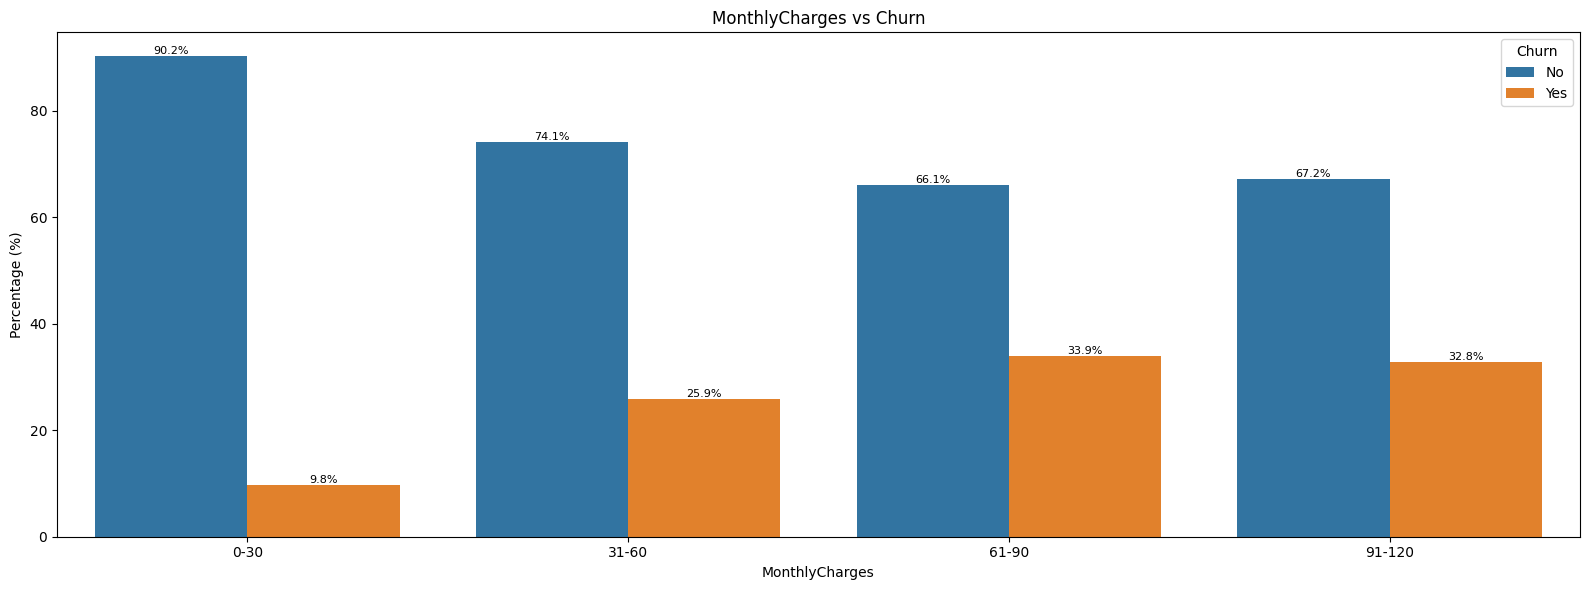

In [44]:
MonthlyCharges_Churn = (
    df.groupby('MonthlyCharges_Group')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('percentage')
      .reset_index()
)

plt.figure(figsize=(16,6))

ax = sns.barplot(
    data= MonthlyCharges_Churn,
    x='MonthlyCharges_Group',
    y='percentage',
    hue='Churn'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.title('MonthlyCharges vs Churn')
plt.xlabel('MonthlyCharges')
plt.ylabel('Percentage (%)')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

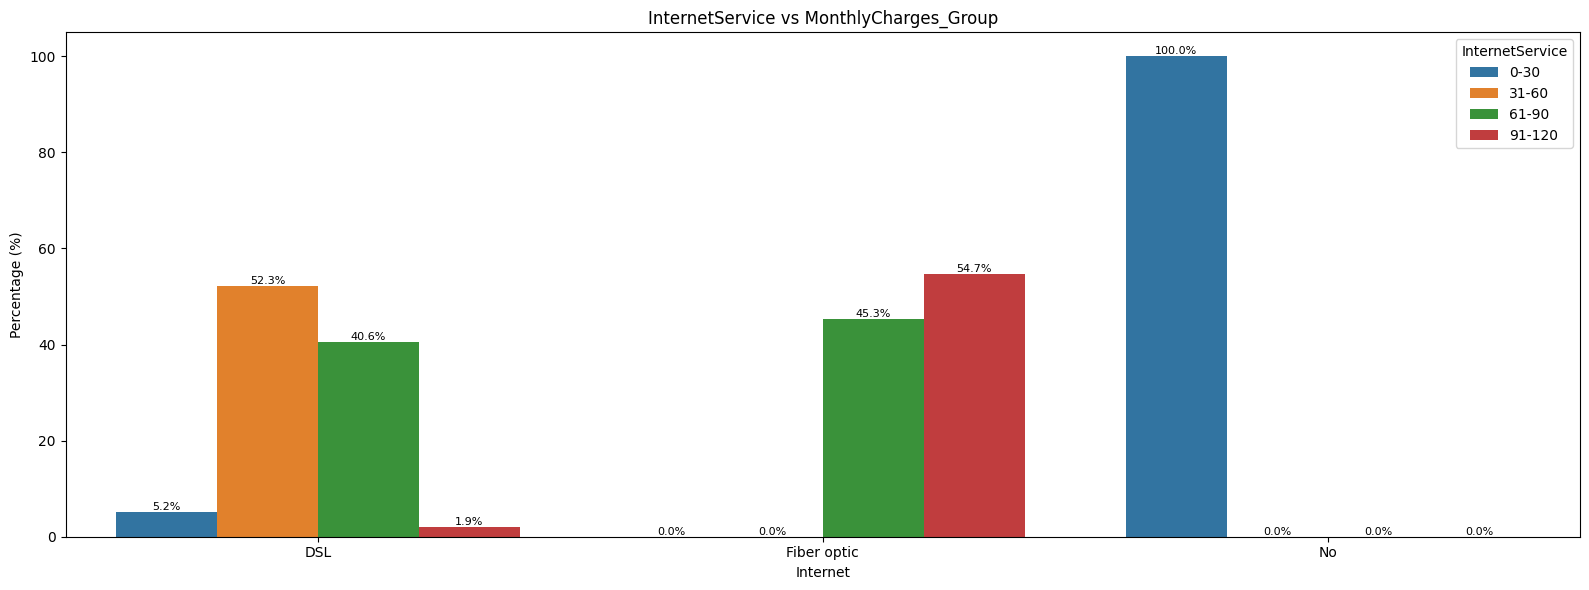

In [45]:
MonthlyCharges_Internet_Churn = (
    df.groupby('InternetService')['MonthlyCharges_Group']
      .value_counts(normalize=True)
      .mul(100)
      .rename('percentage')
      .reset_index()
)

plt.figure(figsize=(16,6))

ax = sns.barplot(
    data= MonthlyCharges_Internet_Churn,
    x='InternetService',
    y='percentage',
    hue='MonthlyCharges_Group'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

plt.title('InternetService vs MonthlyCharges_Group')
plt.xlabel('Internet')
plt.ylabel('Percentage (%)')
plt.legend(title='InternetService')
plt.tight_layout()
plt.show()

### 💡 Insight 6: Higher Monthly Charges Are Associated with Increased Customer Churn

**Observation:**

Customers paying **higher monthly charges** experienced noticeably higher churn rates. The **₹61–90** monthly charge group recorded the highest churn rate (**33.9%**), while customers paying **₹0–30** had the lowest churn rate (**9.8%**).

**Business Insight:**

The supporting analysis reveals that customers paying **higher monthly charges** are predominantly subscribed to **Fiber Optic** internet services, with **54.7%** of Fiber Optic customers falling in the **₹91–120** charge range and **45.3%** in the **₹61–90** range. In contrast, customers without internet service are entirely concentrated in the **₹0–30** pricing group. This suggests that premium internet plans are associated with higher monthly costs, which may contribute to increased customer churn if customers do not perceive sufficient value for the price they pay.

**Recommendation:**

Improve the value proposition of premium Fiber Optic plans by enhancing service quality, offering bundled benefits, and providing loyalty discounts or personalized retention offers. Regularly reviewing premium pricing and customer experience may help reduce churn among high-paying customers.

In [46]:
df['Churn_Numeric'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [48]:
corr = df[['SeniorCitizen',
           'tenure',
           'MonthlyCharges',
           'TotalCharges',
           'Churn_Numeric']].corr(numeric_only=True)

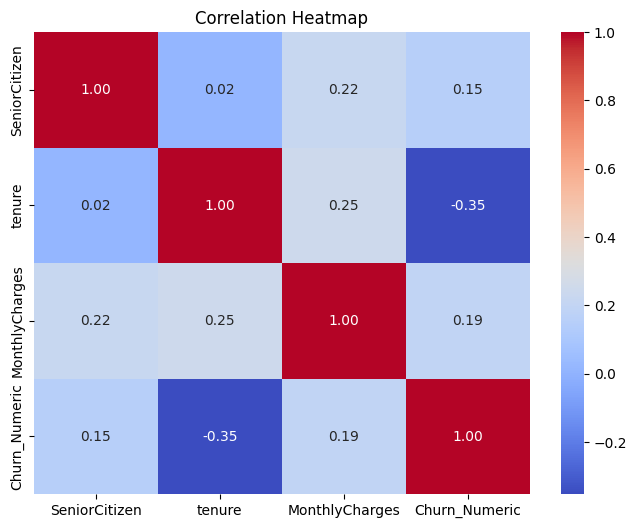

In [49]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

## 📊 Multivariate Analysis: Correlation Heatmap

**Observation:**

The correlation heatmap indicates that **Tenure** has the strongest negative relationship with customer churn, suggesting that long-term customers are less likely to leave the telecom service. **Monthly Charges** show a positive relationship with churn, indicating that customers paying higher monthly fees are more likely to discontinue their services. **Total Charges** exhibit a negative relationship with churn, reflecting that long-standing customers tend to accumulate higher overall spending while remaining loyal. **Senior Citizen** shows only a weak relationship with churn.

**Business Insight:**

The correlation analysis reinforces the findings from the earlier exploratory analyses. Customer retention is more strongly associated with **contract commitment, tenure, pricing, and service value** than with demographic characteristics. Although the observed correlations are moderate rather than strong, they consistently support the business insights derived throughout the analysis.

**Recommendation:**

Telecom companies should prioritize improving customer experience during the early stages of the customer lifecycle, strengthen long-term contract adoption, enhance the value of premium plans, and invest in value-added services such as Online Security and Tech Support to reduce churn.

# 📋 Executive Summary

This project explored customer behavior using the **IBM Telco Customer Churn** dataset to identify the key factors associated with customer churn. Through comprehensive exploratory data analysis, relationships between customer demographics, service subscriptions, contract types, payment methods, pricing, and churn were examined. The analysis revealed that customer retention is strongly associated with contract commitment, service quality, pricing, and value-added services rather than demographic characteristics. These insights can help telecom companies develop targeted retention strategies and improve long-term customer loyalty.


# 🔍 Key Findings

- Customers using **Electronic Check** recorded the highest churn rate, and this was associated with the high proportion of customers on **Month-to-Month contracts**.
- Customers subscribed to **Fiber Optic** internet services experienced the highest churn rate, while customers without **Online Security** were significantly more likely to leave the company.
- **New customers (0–12 months)** exhibited the highest churn rate, whereas customers with longer tenure demonstrated substantially higher retention. Long-term contracts were strongly associated with increased customer loyalty.
- **Gender** showed minimal influence on customer churn, indicating that customer retention is driven primarily by service-related factors rather than demographic characteristics.
- Customers without **Tech Support** experienced considerably higher churn and were predominantly enrolled in **Month-to-Month contracts**, suggesting that both service support and contract commitment influence retention.
- Customers paying **higher monthly charges** were more likely to churn. Supporting analysis showed that these customers were primarily subscribed to **Fiber Optic** internet plans, indicating that premium-priced services require stronger value propositions to improve retention.


# 💼 Business Recommendations

- Encourage customers to upgrade from **Month-to-Month** contracts to **One-Year** or **Two-Year** plans through discounts, loyalty rewards, and bundled service offers.
- Promote **automatic payment methods** such as Credit Card and Bank Transfer by offering billing incentives to improve customer retention.
- Increase adoption of **Online Security** and **Tech Support** by bundling these services with internet plans or providing promotional pricing.
- Improve customer engagement during the **first year** through proactive onboarding, personalized communication, and early retention campaigns.
- Enhance the value of **Fiber Optic** and other premium internet plans by improving service quality, reliability, and customer support to justify higher monthly charges.
- Focus retention strategies on **service quality, pricing, and customer experience** rather than demographic characteristics such as gender.

# ✅ Conclusion

The exploratory analysis demonstrates that **customer churn is primarily associated with service-related and financial factors rather than customer demographics**. Variables such as **contract type, tenure, internet service, technical support, online security, payment method, and monthly charges** play a significant role in customer retention. By strengthening customer support, improving the value of premium plans, encouraging long-term contracts, and enhancing the overall customer experience, telecom companies can effectively reduce churn and build stronger long-term customer relationships.